# Vintage Resale Business - Data Analysis (2021-2025)

**Author:** Richard Rowe
**Skills:** Python · pandas · matplotlib · seaborn · pdfplumber · data cleaning
**GitHub:** [rrowe99](https://github.com/rrowe99)

---

I've been buying and reselling products online since 2021. What started with sneakers, Pokémon cards, and even crypto mining equipment gradually evolved into a vintage clothing and workwear business sold through eBay, Depop, Grailed, Instagram, and in person flea markets throughout New England.

This notebook turns five years of messy raw data (1099-K tax forms, marketplace CSV exports, handwritten market notes, and expense records) into a clean, visual business analysis.

**Questions this notebook answers:**
1. How did the business grow, and where did the money come from?
2. When do sales  happen? (online seasonality vs. market season)
3. Which sales channel is worth it? (price, fees, and take home by platform)
4. What actually makes money? (top items and 2022 item level ROI)
5. Is the business profitable? (revenue vs. expenses, 2024-2025)
6. Data limitations
7. Key takeaways & business implications

## Setup

In [19]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Data parsers (from src/parse_data.py)
from parse_data import (
    parse_item_csvs, parse_1099s, 
    build_annual_summary, build_expenses, build_market_events,
    parse_ebay_transactions, parse_depop_sales, build_notable_items
)

# Styling
PALETTE = {
    "ebay":     "#E53238",
    "grailed":   "#1B1B1B",
    "depop":     "#FF2300",
    "market":    "#4A90D9",
    "instagram": "#C13584",
}
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "font.size": 11})
print("✅ Imports ready")

✅ Imports ready


## Data Sources

The raw data comes from four different source types:
- **CSV exports**: Flyp inventory tracker (2022), eBay Seller Hub, and Depop seller dashboard
- **1099-K PDFS**: IRS tax forms; monthly revenue is extracted with 'pdfplumber' and regular expressions
- **Handwritten market notes**: transcribed by hand into a structured event log
- **Expense summaries**: annual expense breakdowns

A large part of this project was cleaning and standardizing these sources before any analysis could be done. All extraction logic lives in 'src/parse_data.py'

In [20]:
# Load all datasets
items   = parse_item_csvs()            # 2022 item level sales (Flyp)
ebay_tx = parse_ebay_transactions()     # eBay orders 2024-2025
depop_tx = parse_depop_sales()          # Depop sales 2023-2025
monthly = parse_1099s()                 # monthly 1099-K revenue by platform
annual = build_annual_summary()         # annual totals by platform
expenses = build_expenses()             # expense categories by year
markets = build_market_events()         # in person market events

print(f"\nItems (2022):     {len(items)} sold items")
print(f"eBay transactions:  {len(ebay_tx)} orders | avg ${ebay_tx['revenue'].mean():.2f}")
print(f"Depop transactions: {len(depop_tx)} sales | avg ${depop_tx['revenue'].mean():.2f}")
print(f"Monthly revenue:    {len(monthly)} platform-months")
print(f"Annual summary:     {annual['year'].nunique()} years, {annual['platform'].nunique()} platforms")
print(f"Market events:      {len(markets)} events")

  ✓ Flyp CSVs: 59 sold items
  ✓ Transaction_report_20240101_20240331.csv: 11 orders
  ✓ Transaction_report_20240401_20240630.csv: 33 orders
  ✓ Transaction_report_20240701_20240930.csv: 27 orders
  ✓ Transaction_report_20241001_20241231.csv: 20 orders
  ✓ Transaction_report_20250101_20250331.csv: 36 orders
  ✓ Transaction_report_20250401_20250630.csv: 25 orders
  ✓ Transaction_report_20250701_20250930.csv: 38 orders
  → eBay total: 190 orders
  ✓ Depop Sales 02_01_2023 - 04_01_2023.csv: 13 sales
  ✓ Depop Sales 03_01_2024 - 05_29_2024.csv: 94 sales
  ✓ Depop Sales 04_01_2023 - 06_30_2023.csv: 23 sales
  ✓ Depop Sales 06_01_2024 - 08_31_2024.csv: 53 sales
  ✓ Depop Sales 07_01_2023 - 09_30_2023.csv: 20 sales
  ✓ Depop Sales 09_01_2024 - 11_30_2024.csv: 11 sales
  ✓ Depop Sales 10_01_2023 - 12_30_2023.csv: 77 sales
  ✓ Depop Sales 12_01_2023 - 02_29_2024.csv: 73 sales
  ✓ Depop Sales 12_01_2024 - 02_28_2025.csv: 14 sales
  → Depop total: 378 sales
 ✓ Paypal_1099K_2022.pdf: 11 months
 ✓ 

## 1. How did the business grow, and where did the money come from?

The business changed a lot over five years:
- **2021:** Sneakers and collectibles on eBay, before the vintage focus
- **2022:** Grailed (via Paypal) as the main channel; started new eBay in October
- **2023:** eBay became the main online channel; added Depop
- **2024:** First full season of in person flea markets
- **2025:** eBay grew; Depop wound down; the best single market day (Brimfield, May)

In [21]:
# Annual totals at a glance
summary = annual.groupby("year")["gross_revenue"].sum().reset_index()
summary.columns = ["Year", "Gross Revenue"]
summary["YoY Growth"] = summary["Gross Revenue"].pct_change().mul(100).round(1).astype(str) + "%"
summary["Gross Revenue"] = summary["Gross Revenue"].map("${:,.2f}".format)
print("=== Annual Revenue Summary ===")
display(summary)

=== Annual Revenue Summary ===


,Year,Gross Revenue,YoY Growth
0,2021,"$9,149.72",NaN
1,2022,"$8,265.94",-9.7%
2,2023,"$19,963.31",141.5%
3,2024,"$36,274.12",81.7%
4,2025,"$31,021.61",-14.5%


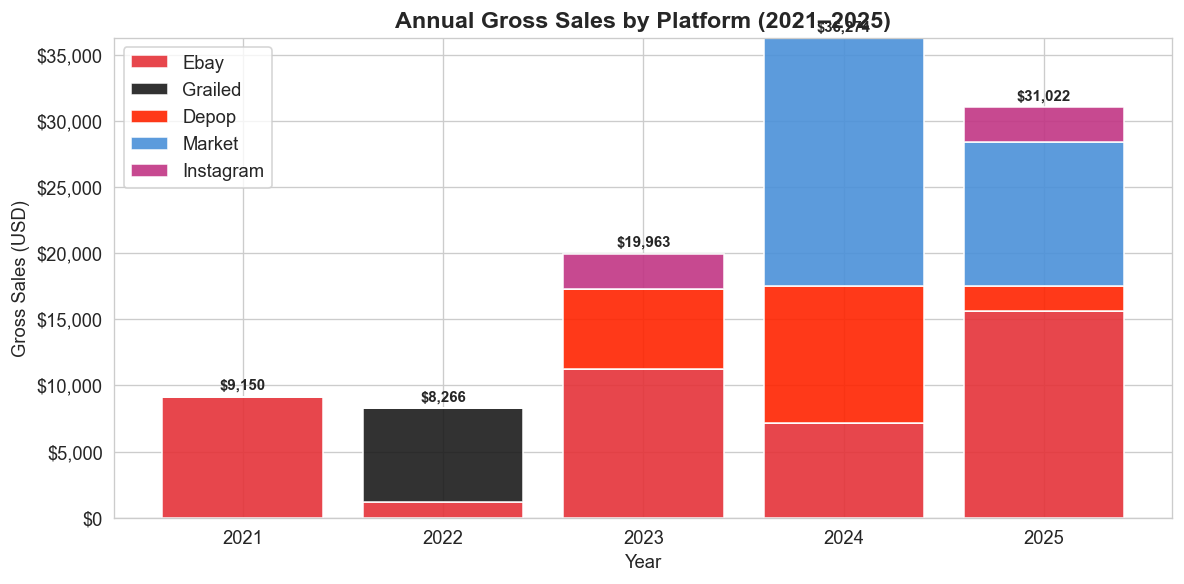

In [22]:
pivot = annual.pivot_table(
    index="year", columns="platform", values="gross_revenue", aggfunc="sum"
).fillna(0)

fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(pivot))
for plat, color in PALETTE.items():
    if plat in pivot.columns:
        ax.bar(pivot.index.astype(str), pivot[plat], bottom=bottom,
               label=plat.title(), color=color, alpha=0.9, edgecolor="white")
        bottom += pivot[plat].values

for i, total in enumerate(bottom):
    ax.text(i, total + 300, f"${total:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Annual Gross Sales by Platform (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../images/01_annual_sales_by_platform.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Group platforms into two channels: online marketplaces vs. in person (markets + Instagram contacts)
annual["channel"] = np.where(annual["platform"].isin(["market", "instagram"]), "In-person", "Online")

channel = annual.pivot_table(
    index="year", columns="channel", values="gross_revenue", aggfunc="sum"
).fillna(0)
channel["In-person %"] = channel["In-person"] / (channel["In-person"] + channel["Online"]) * 100

formatted = channel.copy()
formatted["Online"]      = formatted["Online"].map("${:,.0f}".format)
formatted["In-person"]   = formatted["In-person"].map("${:,.0f}".format)
formatted["In-person %"] = formatted["In-person %"].map("{:.1f}%".format)
display(formatted)

channel,In-person,Online,In-person %
year,,,
2021,$0,"$9,150",0.0%
2022,$0,"$8,266",0.0%
2023,"$2,700","$17,263",13.5%
2024,"$18,800","$17,474",51.8%
2025,"$13,500","$17,522",43.5%


In [24]:
# Break online sales into volume x price
online = annual[annual["channel"] == "Online"].groupby("year").agg(
    sales=("gross_revenue", "sum"),
    transactions=("num_transactions", "sum"),
)
online["avg_per_sale"] = online["sales"] / online["transactions"]

formatted = online.copy()
formatted["sales"]        = formatted["sales"].map("${:,.0f}".format)
formatted["avg_per_sale"] = formatted["avg_per_sale"].map("${:,.0f}".format)
display(formatted)

,sales,transactions,avg_per_sale
year,,,
2021,"$9,150",33,$277
2022,"$8,266",59,$140
2023,"$17,263",178,$97
2024,"$17,474",303,$58
2025,"$17,522",185,$95


**Finding:**
- **Online sales were flat (~$17.5k/year, 2023–2025), but the online business model changed.** 2024 ran on volume (303 sales averaging $58, driven by Depop); 2025 brought in the same money from 118 fewer sales averaging $95 (driven by eBay). Fewer, higher value sales means less time spent listing, packing, and shipping for the same revenue.
- **Nearly all growth after 2023 came from in person selling**, rising from $2.7k in 2023 to $18.8k in 2024, more than half of that year's sales.
- **Average sale price tells the story of the pivot**: $277 in 2021 (sneakers) down to $58–$97 as the business shifted to vintage clothing.

*Note: 2021 reflects a different product mix (sneakers/collectibles), and 2022 eBay covers only Oct–Dec, so growth from 2021–2022 isn't a like-for-like comparison.*

## 2. When do sales happen?

Two different calendars drive this business: online sales can happen any month, while in person markets are seasonal (mostly June-November in New England). This section looks at online seasonality first, then at how the market season fits around it.

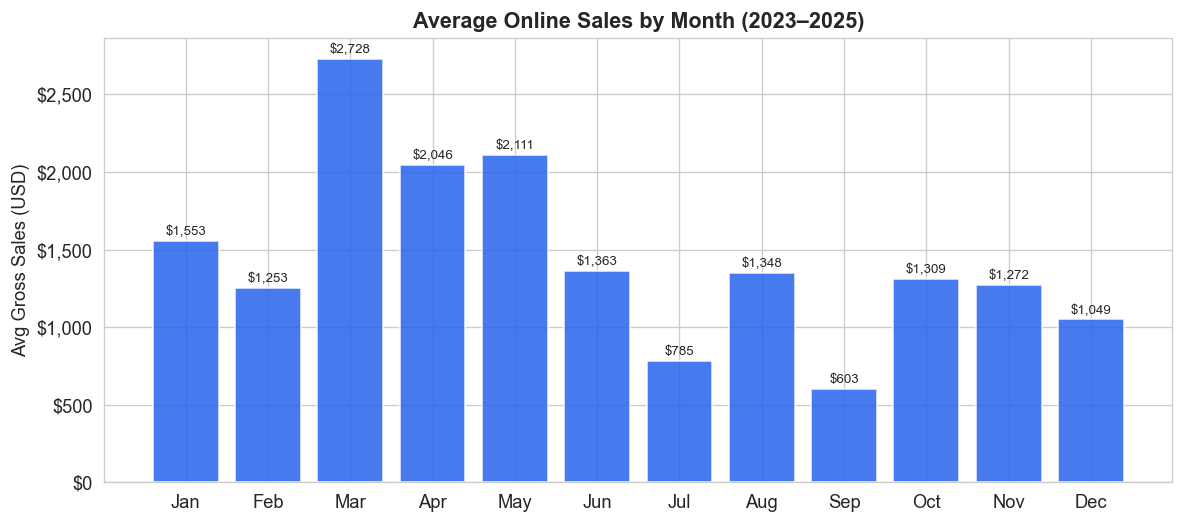

Strongest month: March ($2,728 avg)
Weakest month:   September ($603 avg)


In [25]:
import calendar

# Online sales by calendar month, averaged over the three full years (2023-2025)
online_months = monthly[monthly["year"].between(2023, 2025)].pivot_table(
    index="year", columns="month", values="gross_revenue", aggfunc="sum"
).reindex(columns=range(1, 13)).fillna(0)

seasonal = online_months.mean()
month_names = [calendar.month_abbr[m] for m in seasonal.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(month_names, seasonal.values, color="#2563EB", alpha=0.85, edgecolor="white")
for bar, val in zip(bars, seasonal.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 40, f"${val:,.0f}", ha="center", fontsize=8)

ax.set_title("Average Online Sales by Month (2023–2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../images/02_online_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Strongest month: {calendar.month_name[seasonal.idxmax()]} (${seasonal.max():,.0f} avg)")
print(f"Weakest month:   {calendar.month_name[seasonal.idxmin()]} (${seasonal.min():,.0f} avg)")

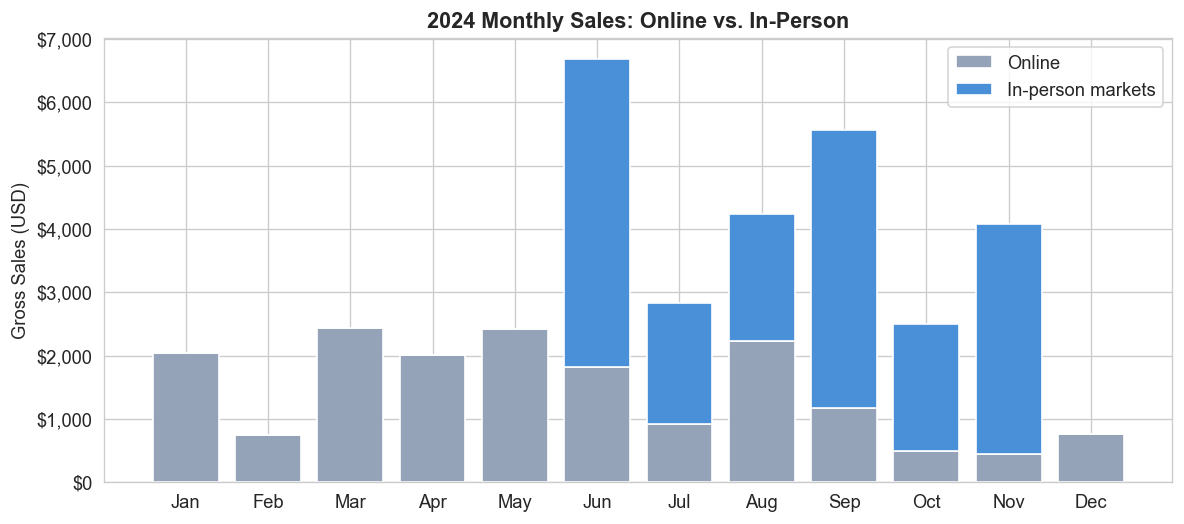

Online sales Jan-May (5 months, before markets): $9,638
Online sales Jun-Nov (6 months, market season):  $7,074
In-person sales Jun-Nov:                         $18,800


In [26]:
y = 2024
online_by_month   = monthly[monthly["year"] == y].groupby("month")["gross_revenue"].sum().reindex(range(1, 13), fill_value=0)
inperson_by_month = markets[markets["year"] == y].groupby("month")["richie_revenue"].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [calendar.month_abbr[m] for m in range(1, 13)]
ax.bar(labels, online_by_month.values, label="Online", color="#94A3B8", edgecolor="white")
ax.bar(labels, inperson_by_month.values, bottom=online_by_month.values,
       label="In-person markets", color=PALETTE["market"], edgecolor="white")

ax.set_title(f"{y} Monthly Sales: Online vs. In-Person", fontsize=13, fontweight="bold")
ax.set_ylabel("Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../images/03_2024_online_vs_inperson_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

pre_season = online_by_month.loc[1:5].sum()
in_season  = online_by_month.loc[6:11].sum()
print(f"Online sales Jan-May (5 months, before markets): ${pre_season:,.0f}")
print(f"Online sales Jun-Nov (6 months, market season):  ${in_season:,.0f}")
print(f"In-person sales Jun-Nov:                         ${inperson_by_month.sum():,.0f}")

**Finding:**
- **Spring is the strongest online season, not the holidays.** March averages ~$2,700 in online sales, and March–May are consistently the best stretch. November–December average only ~$1,000–1,300.
- **Fall is the online low point**: September is the weakest month on average (~$600), and October–December stay below spring levels.
- **Markets fill part of the gap.** The 2024 market season (June–November) brought in $18,800, peaking in June and September.
- **Online sales dropped during market season.** In 2024, online sales over six market months ($7.1k) were lower than in the five months before markets started ($9.6k), with October–November falling below $500 each.

*Owner context: the fall slowdown lines up with the school calendar. From September onward I was back in school and spending less time listing and shipping, while weekend markets competed for the time I did have. This seasonality reflects my available time as much as buyer demand, so the holiday dip shouldn't be read as low demand for vintage clothing in Q4.*

## 3. Which sales channel is wroth it?

Comparing channels faily takes care. eBay's reported "revenue" includes the shipping the buyer paid, while Depop's export lists item price and buyer shipping separately. To compare them on equal terms, this section measures both platforms the same way:
-**Gross** = item price + buyer-paid shipping
- **Fee %** = total platform fees + total gross (weighted by dollars, not averaged per sale)
- **Take-home** = gross - platform fees (before shipping labels and cost of goods, which aren't tracked per sale)

In [27]:
# Put both platforms on the same basis: gross = item price + buyer-paid shipping
ebay  = ebay_tx.assign(item_price=ebay_tx["item_subtotal"], gross=ebay_tx["revenue"])
depop = depop_tx.assign(item_price=depop_tx["revenue"], gross=depop_tx["revenue"] + depop_tx["shipping_rev"])

online_tx = pd.concat([ebay, depop], ignore_index=True)[
    ["platform", "sold_date", "item_price", "gross", "platform_fee"]
]
online_tx["take_home"] = online_tx["gross"] - online_tx["platform_fee"]

compare = online_tx.groupby("platform").agg(
    sales=("gross", "count"),
    avg_item_price=("item_price", "mean"),
    median_item_price=("item_price", "median"),
    gross=("gross", "sum"),
    fees=("platform_fee", "sum"),
    take_home=("take_home", "sum"),
)
compare["fee_pct"] = compare["fees"] / compare["gross"] * 100
compare["take_home_per_sale"] = compare["take_home"] / compare["sales"]

display(compare.round(2))

,sales,avg_item_price,median_item_price,gross,fees,take_home,fee_pct,take_home_per_sale
platform,,,,,,,,
depop,378,35.68,30.0,16591.06,2114.7,14476.36,12.75,38.30
ebay,190,86.29,50.0,18182.15,2515.0,15667.15,13.83,82.46


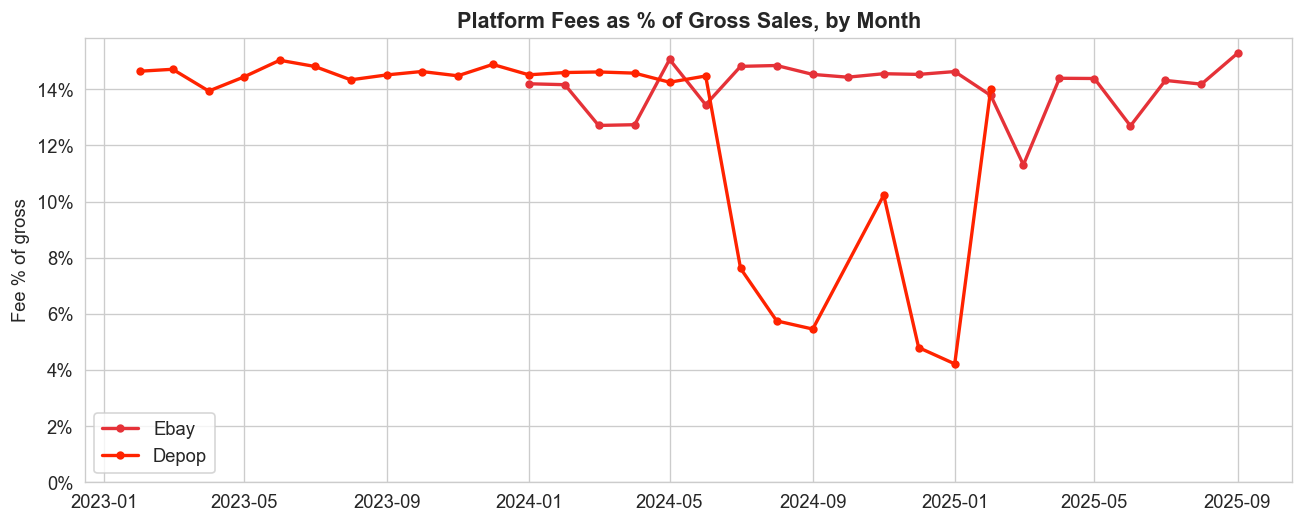

In [28]:
online_tx["month"] = online_tx["sold_date"].dt.to_period("M").dt.to_timestamp()

fee_trend = online_tx.groupby(["month", "platform"]).agg(
    gross=("gross", "sum"), fees=("platform_fee", "sum")
).reset_index()
fee_trend["fee_pct"] = fee_trend["fees"] / fee_trend["gross"] * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
for plat in ["ebay", "depop"]:
    d = fee_trend[fee_trend["platform"] == plat]
    ax.plot(d["month"], d["fee_pct"], marker="o", markersize=4, linewidth=2,
            color=PALETTE[plat], label=plat.title())

ax.set_title("Platform Fees as % of Gross Sales, by Month", fontsize=13, fontweight="bold")
ax.set_ylabel("Fee % of gross")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.savefig("../images/04_platform_fee_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:**
- **On fees alone, Depop was the cheaper platform.** Measured on the same basis (fees ÷ item price + buyer shipping), Depop took 12.7% vs. eBay's 13.8%. Depop's fee rate also fell from ~14.5% to ~5–6% starting in July 2024, which matches Depop removing its 10% selling fee for US sellers in mid-2024. eBay's stayed flat at ~14%.
- **But eBay paid more than twice as much per sale.** eBay's typical item sold for more (median $50 vs. $30), so each eBay sale brought in **$82 in take-home vs. $38 on Depop**. Every sale takes roughly the same work to photograph, list, pack, and ship, so take home per sale matters more than fee percentage.
- **This explains the shift from Depop to eBay in 2025**: Depop sold more items, but eBay paid much better for the same effort. It's also the reason 2025 matched 2024's online sales with 118 fewer orders (Question 1). Notably, this shift happened *after* Depop cut its fees, so lower fees alone weren't enough to keep lower priced items online.

*Owner context: the shift was deliberate. Lower priced items (the typical ~$30 Depop sale) weren't worth the time to photograph, list, and ship when they sold quickly at in person markets with none of that work. I moved those items to markets and kept online listings, mainly eBay, for higher value pieces where the take home justified the effort.*

*Methodology note: an earlier version of this analysis reported Depop fees as higher (17.4% vs 14.6%). That comparison divided Depop fees by item price only while eBay's figure included shipping, and it averaged per-sale percentages instead of weighting by dollars. Both issues are corrected here.*